Progetto di Cavallari Anna matr. 1099291 e Gobbo Chiara matr.1096072

ANALISI SU DATASET AI JOB RECCOMENDATION 
- preprocessing
- distribuzione delle variabili
- clustering

importazione librerie

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# from sklearn.datasets import load_iris                 non serve
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import chi2_contingency

print('Librerie caricate correttamente.') 

Librerie caricate correttamente.


Caricamento dati:

In [3]:
file_path = "ds/job_recommendation_dataset.csv"
df = pd.read_csv(file_path)
print(f"Dataset caricato: {df.shape[0]:,} righe × {df.shape[1]} colonne")

Dataset caricato: 50,000 righe × 7 colonne


Controllo parte iniziale del dataset, prime 5 righe e le informazioni su di esso:

In [4]:
print(df.head())
print(df.info())

                         Job Title                      Company  \
0              Early years teacher               Richardson Ltd   
1         Counselling psychologist  Ramos, Santiago and Stewart   
2        Radio broadcast assistant                 Franco Group   
3     Designer, exhibition/display                  Collins Inc   
4  Psychotherapist, dance movement                 Barker Group   

        Location Experience Level    Salary    Industry  \
0         Sydney     Senior Level   87000.0  Healthcare   
1  San Francisco        Mid Level   50000.0   Marketing   
2       New York        Mid Level   77000.0  Healthcare   
3         Berlin     Senior Level   90000.0    Software   
4         Sydney      Entry Level  112000.0  Healthcare   

                                     Required Skills  
0                                    Pharmaceuticals  
1                   Google Ads, SEO, Content Writing  
2  Patient Care, Nursing, Medical Research, Pharm...  
3                     

Controllo missing nel dataset:

In [5]:
missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'percent': df.isnull().mean() * 100
}).query('count > 0').sort_values('percent', ascending=False)


if missing.empty:
    print('Nessun valore mancante nel dataset!')
else:
    print(f'{len(missing)} colonne con valori mancanti:')
    display(missing.style.bar(subset=['percent'], color='#d65f5f'))


Nessun valore mancante nel dataset!


Stampa delle variabili categoriali presenti:

In [6]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f'Colonne categoriche ({len(cat_cols)}): {cat_cols}')

Colonne categoriche (6): ['Job Title', 'Company', 'Location', 'Experience Level', 'Industry', 'Required Skills']


informazioni utili sul dataset

In [7]:
df.info()
df.shape
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Job Title         50000 non-null  str    
 1   Company           50000 non-null  str    
 2   Location          50000 non-null  str    
 3   Experience Level  50000 non-null  str    
 4   Salary            50000 non-null  float64
 5   Industry          50000 non-null  str    
 6   Required Skills   50000 non-null  str    
dtypes: float64(1), str(6)
memory usage: 2.7 MB


Job Title           0
Company             0
Location            0
Experience Level    0
Salary              0
Industry            0
Required Skills     0
dtype: int64

box plot

In [8]:
df.columns

Index(['Job Title', 'Company', 'Location', 'Experience Level', 'Salary',
       'Industry', 'Required Skills'],
      dtype='str')

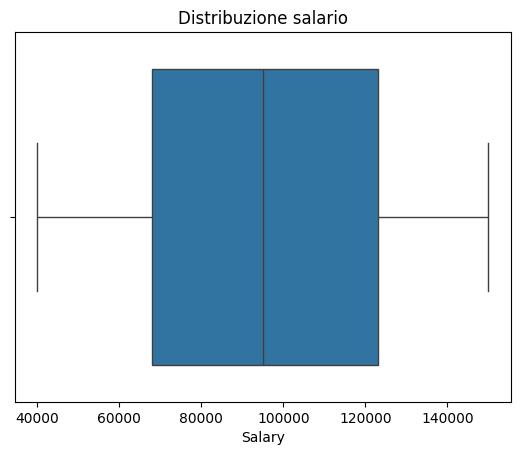

In [ ]:
sns.boxplot(x=df['Salary'])
plt.title("Distribuzione salario")
plt.show()

borx plot di confronto delle variabili
- salario rispetto al livello di educazione

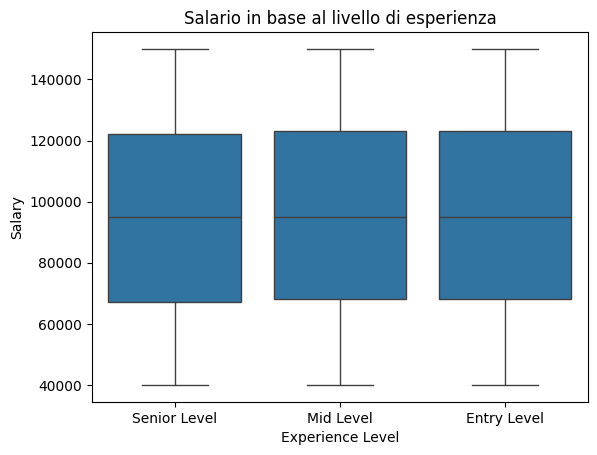

In [ ]:
sns.boxplot(x='Experience Level', y='Salary', data=df)
plt.title("Salario in base al livello di esperienza")
plt.show()

Dal box plot si osserva che il salario non varia significativamente tra i diversi livelli di esperienza.
Questo potrebbe indicare che nel dataset non esiste una forte relazione tra esperienza e salario, oppure che i dati sono distribuiti in modo uniforme.

salario rispetto alla città:

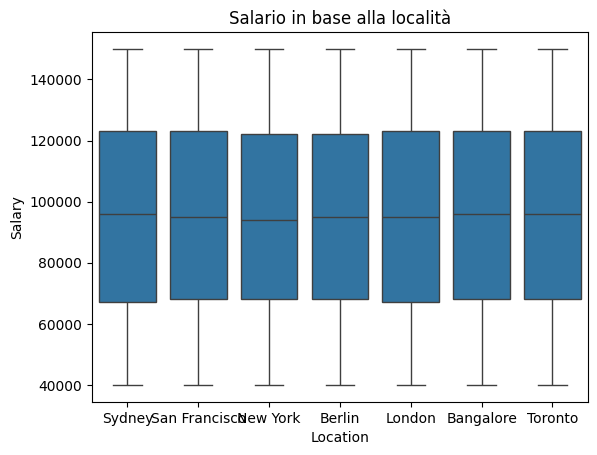

In [ ]:
sns.boxplot(x='Location', y='Salary', data=df)
plt.title("Salario in base alla località")
plt.show()

possiamo notare che anche in questo caso non ci son delle differenze rilevanti ma minime, ad esempio per new york possiamo notare che il terzo quartile tocca un livello di salario più basso rispetto alle altre città, mentre Bangalore il suo primo quartile parte da un livello di salario base più alto. La mediana più alta si trova in Bangalore

salario rispetto al settore di lavoro:

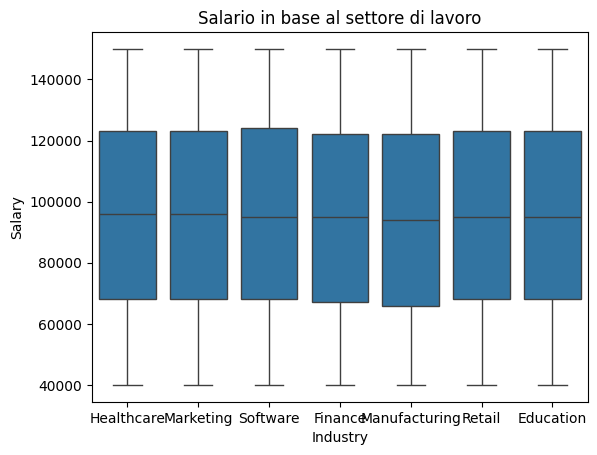

In [ ]:
sns.boxplot(x='Industry', y='Salary', data=df)
plt.title("Salario in base al settore di lavoro")
plt.show()

osservando questo boxplot possiamo notare che il settore manufatturiero è quello con la retribuzion più bassa generalmente, si può notare da media, mediana e l'interquartilico. 

Colonne numeriche: ['Salary']


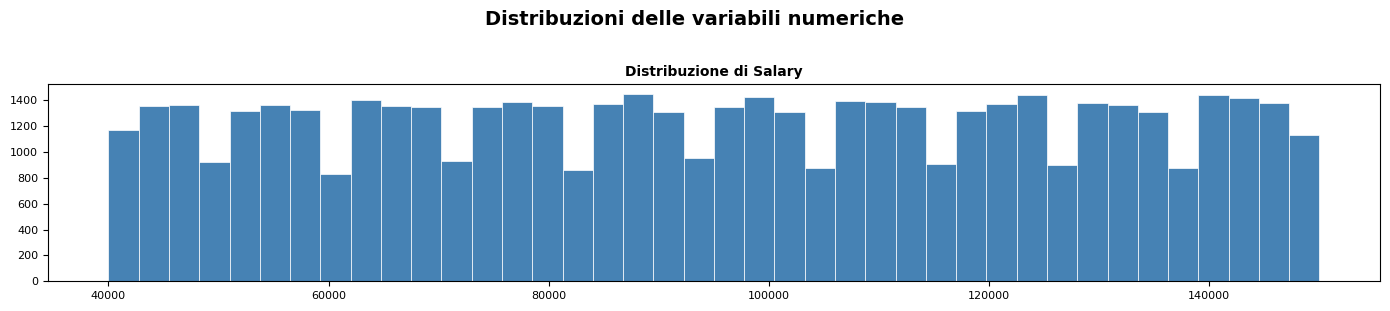

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print("Colonne numeriche:", num_cols)

# Numero di feature numeriche
n = len(num_cols)

# Numero di righe necessarie
nrows = (n + 1 - 1) // 1 # 1 perchè cè' solo una colonna numerica

# Crea figura e assi
fig, axes = plt.subplots(nrows, 1, figsize=(14, nrows * 3))
axes = np.array(axes).reshape(-1)
axes = axes.flatten()

# Istogrammi
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'Distribuzione di {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)

# Nasconde gli assi vuoti
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuzioni delle variabili numeriche',
            fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

Normalizzazione della colonna del salario, deve essere normalizzato perchè altrimenti le variabili con più valori e più distanti vengono ritenute più importanti rispetto a quelle con pochi valori.

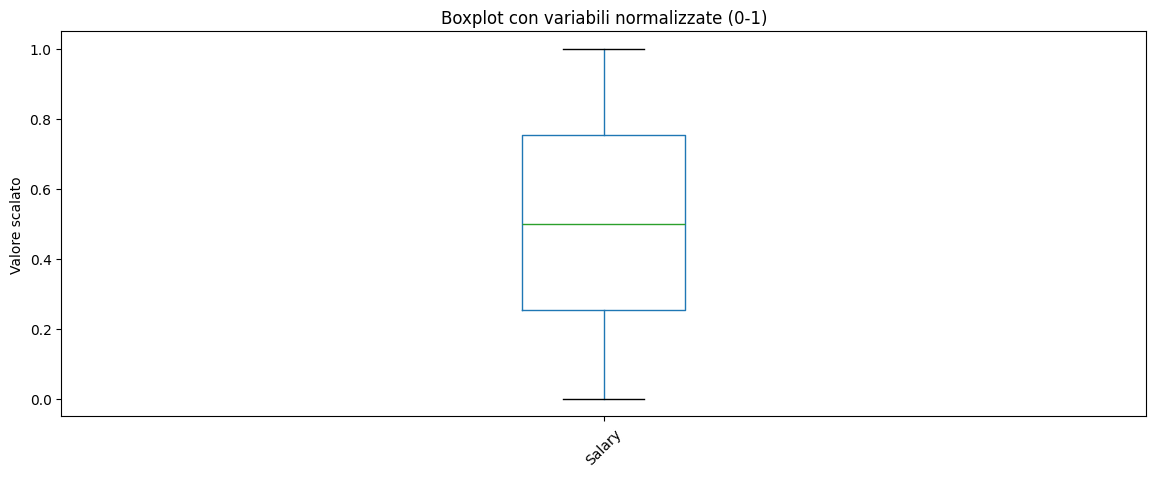

In [11]:
scaler = MinMaxScaler()

# Applica lo scaler e crea il nuovo DataFrame "scalato"
df_scaled = pd.DataFrame(
    scaler.fit_transform(df[num_cols]), 
    columns=num_cols
)

plt.figure(figsize=(14, 5))
df_scaled.boxplot(rot=45, grid=False)
plt.title('Boxplot con variabili normalizzate (0-1)', fontsize=12)
plt.ylabel('Valore scalato')
plt.show()

Variabili categoriche:

In [12]:
# Cardinalità (numero di valori unici) per ogni colonna categorica
cardinality = df[cat_cols].nunique().sort_values(ascending=False)
print('Cardinalità colonne categoriche:')
display(cardinality.to_frame('n_unique'))

Cardinalità colonne categoriche:


,n_unique
Company,37022
Required Skills,1559
Job Title,639
Location,7
Industry,7
Experience Level,3


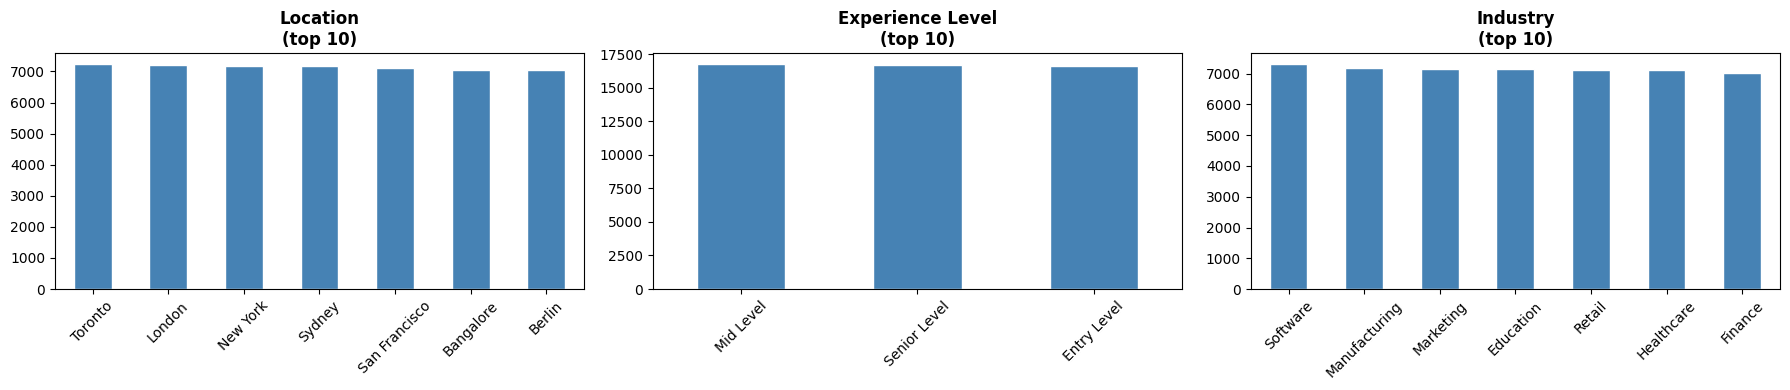

In [ ]:
low_card = [c for c in cat_cols if df[c].nunique() <= 50]

if low_card:
    n = len(low_card)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]
    
    for ax, col in zip(axes, low_card):
        counts = df[col].value_counts().head(10)
        counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(f'{col}\n(top 10)', fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print('Tutte le colonne categoriche hanno alta cardinalità (> 50 valori).')

In [14]:
n_dup = df.duplicated().sum()
print(f'Righe duplicate: {n_dup} ({n_dup / len(df) * 100:.2f}%)')

Righe duplicate: 0 (0.00%)


Correlazioni

In [15]:
print(df.columns.tolist())

['Job Title', 'Company', 'Location', 'Experience Level', 'Salary', 'Industry', 'Required Skills']


Risultati Test Chi-Quadrato tra 'Industry' e 'Experience Level':
P-value: 0.4258
Non c'è una relazione statistica significativa tra queste due variabili.


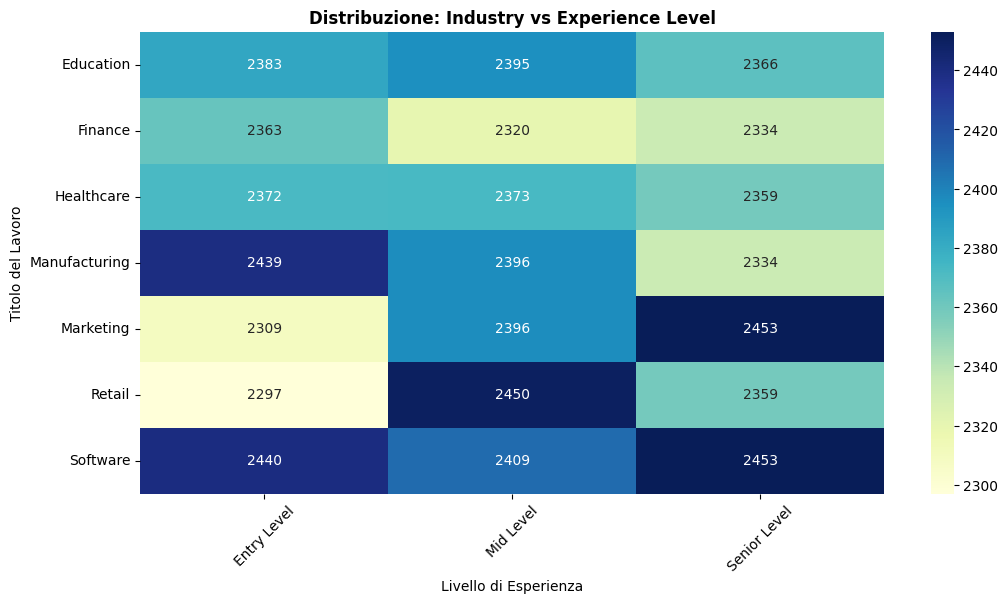

In [ ]:
cat_cols = ['Industry', 'Experience Level'] 

# Tabella di Contingenza
contingency_table = pd.crosstab(df[cat_cols[0]], df[cat_cols[1]])

# Chi-Quadrato
chi2, p, dof, ex = chi2_contingency(contingency_table)

print(f"Risultati Test Chi-Quadrato tra '{cat_cols[0]}' e '{cat_cols[1]}':")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("Esiste una relazione significativa tra il Ruolo e il Livello di Esperienza.")
else:
    print("Non c'è una relazione statistica significativa tra queste due variabili.")

plt.figure(figsize=(12, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Distribuzione: {cat_cols[0]} vs {cat_cols[1]}', fontweight='bold')
plt.xlabel('Livello di Esperienza')
plt.ylabel('Settore industriale')
plt.xticks(rotation=45)
plt.show()

Si accetta l'ipotesi nulla: non esiste una relazione statistica significativa tra il settore industriale e il livello di esperienza dei dipendenti. La distribuzione dell'esperienza appare uniforme e indipendente dal settore di riferimento